In [3]:
import pandas as pd

redwine = pd.read_csv("winequality-red.csv", sep=";")
X, y = redwine.iloc[:, :-1], redwine.iloc[:, -1]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

model = Sequential()
model.add(Input(shape=(11,)))
# model.add(Dense(100, activation='sigmoid'))
model.add(Dense(200, activation='sigmoid'))
model.add(BatchNormalization())
# model.add(Dense(200, activation='relu'))
model.add(Dense(200, activation='sigmoid'))
model.add(BatchNormalization())
# model.add(Dense(50, activation='tanh'))
model.add(Dense(200, activation='sigmoid'))
model.add(BatchNormalization())
model.add(Dense(10, activation='softmax'))
model.summary()

W0000 00:00:1779002750.358139 2570841 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1779002750.379054 2570841 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1779002750.487282 2570841 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 29802 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5090, pci bus id: 0000:81:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,210 (340.66 KB)

 Trainable params: 86,010 (335.98 KB)

 Non-trainable params: 1,200 (4.69 KB)

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard

checkpoint = ModelCheckpoint("best_model.keras", save_best_only=True)
tensorboard = TensorBoard(log_dir="./logs-activation", histogram_freq=1, embeddings_freq=1)

In [7]:
# history = model.fit(X_train, y_train,
#                    batch_size=200, epochs=300)
history = model.fit(X_train, y_train,
                    batch_size=200, epochs=300, callbacks=[checkpoint, tensorboard],
                    validation_data=(X_test, y_test))

Epoch 1/300


I0000 00:00:1779002752.850092 2571371 service.cc:153] XLA service 0x7a4c5c035c30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779002752.850129 2571371 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5090, Compute Capability 12.0a (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1779002752.906957 2571371 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779002753.074241 2571371 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779002753.101674 2571371 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2891__.32


1/6 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.0700 - loss: 3.4469

I0000 00:00:1779002755.805707 2571371 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1779002756.044183 2571369 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2891__.32


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 705ms/step - accuracy: 0.3094 - loss: 2.4348 - val_accuracy: 0.2300 - val_loss: 3.9215
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4912 - loss: 1.8587 - val_accuracy: 0.3150 - val_loss: 4.3209
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5388 - loss: 1.7429 - val_accuracy: 0.2400 - val_loss: 4.7581
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5721 - loss: 1.6660 - val_accuracy: 0.2800 - val_loss: 4.2296
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5630 - loss: 1.5991 - val_accuracy: 0.2375 - val_loss: 4.1478
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5922 - loss: 1.5629 - val_accuracy: 0.2725 - val_loss: 4.0976
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5880 - loss: 1.5245 - val_accuracy: 0.2275 - val_loss: 3.6506
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5955 - loss: 1.4684 - val_accuracy: 0.2700 - val_loss: 3.5319
Epo

In [8]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss, accuracy)

1.6590871810913086 0.5699999928474426


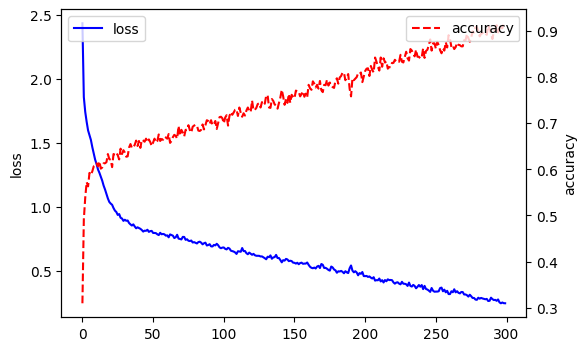

In [9]:
import matplotlib.pyplot as plt
 
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(history.history['loss'], 'b-', label='loss')
ax1.set_ylabel('loss')
ax1.legend(loc='upper left')
 
ax2 = ax1.twinx()
ax2.plot(history.history['accuracy'], 'r--', label='accuracy')
ax2.set_ylabel('accuracy')
ax2.legend(loc='upper right')
plt.show()

In [10]:
# 예측한 결과 처음 5개 출력해보기
import numpy as np
pred = model.predict(X_test)
# print(np.argmax(pred[:5], axis=1))
print(y_test[:5].values)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
[5 6 6 7 5]


- 텐서보드 실행 명령: `tensorboard --logdir=./logs`
- 브라우저에서 `http://localhost:6006`으로 확인


[Colab에서 텐서보드 실행]
- %load_exttensorboard
- %tensorboard--logdirlogs/